In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex','grid'])
from pathlib import Path
import numpy as np

In [3]:
seed = 69
rng = np.random.default_rng(seed)
FIG_DIR = Path("/Users/michelefanelli/Documents/Thesis/Latex/Figures")
FIG_DIR.mkdir(exist_ok=True)

In [4]:
df = pd.read_csv("Data/log_returns.csv", index_col=0, parse_dates=True)
df_wnan = pd.read_csv("Data/test.csv", index_col=0, parse_dates=True)

# Imputation models

Apply every model from `Models.py` to the masked panel `df_wnan` and score the
reconstruction against the complete panel `df`. Models are run in the order
defined in the module: Deletion → Student-t EM → KNN → BRITS → SAITS → CSDI.

In [5]:
import numpy as np
from Models import (
    DeletionImputer,
    StudentTEMImputer,
    KNNReturnImputer,
    BRITSImputer,
    SAITSImputer,
    CSDIImputer,
)

# df       -> complete ground-truth panel (no missing values)
# df_wnan  -> same panel with values masked out (what we impute)
X_true = df.to_numpy(dtype=float)
X_nan = df_wnan.to_numpy(dtype=float)

# Evaluation targets: cells masked out in df_wnan but known in df.
eval_mask = np.isnan(X_nan) & ~np.isnan(X_true)
print(f"panel shape: {X_nan.shape}  |  cells to evaluate: {int(eval_mask.sum())}")

panel shape: (4125, 50)  |  cells to evaluate: 20037


### Deletion baseline

Naive complete-case baseline. It drops any row/column that contains a missing
value, so it changes the panel shape and is not directly comparable with the
shape-preserving imputers — it is included only as a reference point.

In [6]:
del_row = DeletionImputer(strategy="row").fit_transform(df_wnan)
print(f"row deletion : {X_nan.shape} -> {del_row.shape}")

row deletion : (4125, 50) -> (18, 50)


In [7]:
zero_replace = df_wnan.fillna(0)

### Fit & transform the imputers

Each imputer reconstructs the full `(T, N)` panel from `df_wnan`. Observed entries
are preserved exactly, so only the masked cells are actually filled in.

In [9]:
# Shape-preserving imputers, each reconstructing the full (T, N) panel from df_wnan.
# BRITS / SAITS / CSDI are deep models (heavier; epochs kept modest here) and need
# the optional `pypots` package -- if it is missing they are skipped with a message.
models = {
    "Student-t EM": StudentTEMImputer(max_iter=100, nu=5.0),
    "KNN":          KNNReturnImputer(n_neighbors=5, weights="distance"),
    "BRITS":        BRITSImputer(epochs=200),
    "SAITS":        SAITSImputer(epochs=500),
    "CSDI":         CSDIImputer(epochs=200),
}

In [10]:

imputed = {}

In [11]:
model = "Student-t EM"
X_imp = models[model].fit_transform(df_wnan)
imputed[model] = pd.DataFrame(X_imp, index=df_wnan.index, columns=df_wnan.columns)
print(f"{model:13s} imputed -> {X_imp.shape}")

Student-t EM  imputed -> (4125, 50)


In [12]:
model = "KNN"
X_imp = models[model].fit_transform(df_wnan)
imputed[model] = pd.DataFrame(X_imp, index=df_wnan.index, columns=df_wnan.columns)
print(f"{model:13s} imputed -> {X_imp.shape}")

KNN           imputed -> (4125, 50)


In [75]:
model = "BRITS"
X_imp = models[model].fit_transform(df_wnan)
imputed[model] = pd.DataFrame(X_imp, index=df_wnan.index, columns=df_wnan.columns)
print(f"{model:13s} imputed -> {X_imp.shape}")

2026-06-17 11:16:43 [INFO]: No given device, using default device: cpu
2026-06-17 11:16:43 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2026-06-17 11:16:43 [INFO]: Using customized MAE as the training loss function.
2026-06-17 11:16:43 [INFO]: Using customized MSE as the validation metric function.
2026-06-17 11:16:43 [INFO]: BRITS initialized with the given hyperparameters, the number of trainable parameters: 118,320
2026-06-17 11:16:45 [INFO]: Epoch 001 - training loss (MAE): 0.1698
2026-06-17 11:16:48 [INFO]: Epoch 002 - training loss (MAE): 0.1454
2026-06-17 11:16:50 [INFO]: Epoch 003 - training loss (MAE): 0.1271
2026-06-17 11:16:53 [INFO]: Epoch 004 - training loss (MAE): 0.1134
2026-06-17 11:16:56 [INFO]: Epoch 005 - training loss (MAE): 0.1037
2026-06-17 11:16:58 [INFO]: Epoch 006 - training loss (MAE): 0.0966
2026-06-17 11:17:01 [INFO]: Epoch 007 - training loss (MAE): 0.0911
2026-06-17 11:17:04 [INFO]: Epoch 008 - training loss (MAE

BRITS         imputed -> (4125, 50)


In [90]:
model = "SAITS"
X_imp = models[model].fit_transform(df_wnan)
imputed[model] = pd.DataFrame(X_imp, index=df_wnan.index, columns=df_wnan.columns)
print(f"{model:13s} imputed -> {X_imp.shape}")

2026-06-17 11:38:13 [INFO]: No given device, using default device: cpu
2026-06-17 11:38:13 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2026-06-17 11:38:13 [INFO]: Using customized MAE as the training loss function.
2026-06-17 11:38:13 [INFO]: Using customized MSE as the validation metric function.
2026-06-17 11:38:13 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 363,642
2026-06-17 11:38:14 [INFO]: Epoch 001 - training loss (MAE): 0.5520
2026-06-17 11:38:15 [INFO]: Epoch 002 - training loss (MAE): 0.4841
2026-06-17 11:38:15 [INFO]: Epoch 003 - training loss (MAE): 0.4316
2026-06-17 11:38:16 [INFO]: Epoch 004 - training loss (MAE): 0.3815
2026-06-17 11:38:16 [INFO]: Epoch 005 - training loss (MAE): 0.3318
2026-06-17 11:38:17 [INFO]: Epoch 006 - training loss (MAE): 0.2854
2026-06-17 11:38:17 [INFO]: Epoch 007 - training loss (MAE): 0.2429
2026-06-17 11:38:18 [INFO]: Epoch 008 - training loss (MAE

SAITS         imputed -> (4125, 50)


### Evaluation

`MSE` / `MAE` measure the direct reconstruction error on the masked cells, while
`CovErr` and `VolErr` measure how well the cross-asset covariance matrix and the
per-asset volatilities are preserved (relative error vs. the ground-truth panel).

In [14]:
def evaluate(X_imp):
    """Direct and financial reconstruction metrics vs. the ground-truth panel `df`.

    MSE / MAE are computed only on the artificially masked cells; CovErr and
    VolErr measure how well the asset covariance matrix and per-asset
    volatilities are preserved (relative error against the complete panel).
    """
    diff = X_imp[eval_mask] - X_true[eval_mask]
    cov_true, cov_imp = np.cov(X_true, rowvar=False), np.cov(X_imp, rowvar=False)
    vol_true, vol_imp = X_true.std(axis=0), X_imp.std(axis=0)
    return {
        "MSE":    np.mean(diff ** 2),
        "MAE":    np.mean(np.abs(diff)),
        "CovErr": np.linalg.norm(cov_imp - cov_true) / np.linalg.norm(cov_true),
        "VolErr": np.mean(np.abs(vol_imp - vol_true) / vol_true),
    }

scores = pd.DataFrame(
    {name: evaluate(X.to_numpy()) for name, X in imputed.items()}
).T
cov_true, cov_imp = np.cov(X_true, rowvar=False), np.cov(del_row, rowvar=False)
vol_true, vol_imp = X_true.std(axis=0), del_row.std(axis=0)
CovErr = np.linalg.norm(cov_imp - cov_true) / np.linalg.norm(cov_true)
VolErr = np.mean(np.abs(vol_imp - vol_true) / vol_true)
scores.loc['Deletion'] = {"MSE": np.nan, "MAE": np.nan, "CovErr": CovErr, "VolErr": VolErr}
scores

,MSE,MAE,CovErr,VolErr
Student-t EM,0.000127,0.007241,0.025250,0.022862
KNN,0.000163,0.008448,0.052860,0.033130
Deletion,NaN,NaN,0.851931,0.271380


In [18]:
zero = zero_replace.to_numpy()
diff = zero[eval_mask] - X_true[eval_mask]

cov_true, cov_imp = np.cov(X_true, rowvar=False), np.cov(zero, rowvar=False)
vol_true, vol_imp = X_true.std(axis=0), zero.std(axis=0)
CovErr = np.linalg.norm(cov_imp - cov_true) / np.linalg.norm(cov_true)
VolErr = np.mean(np.abs(vol_imp - vol_true) / vol_true)
scores.loc['Replace'] = {"MSE": np.mean(diff ** 2), "MAE": np.mean(np.abs(diff)), "CovErr": CovErr, "VolErr": VolErr}
scores

,MSE,MAE,CovErr,VolErr
Student-t EM,0.000127,0.007241,0.025250,0.022862
KNN,0.000163,0.008448,0.052860,0.033130
Deletion,NaN,NaN,0.851931,0.271380
Replace,0.000277,0.011006,0.191976,0.051284


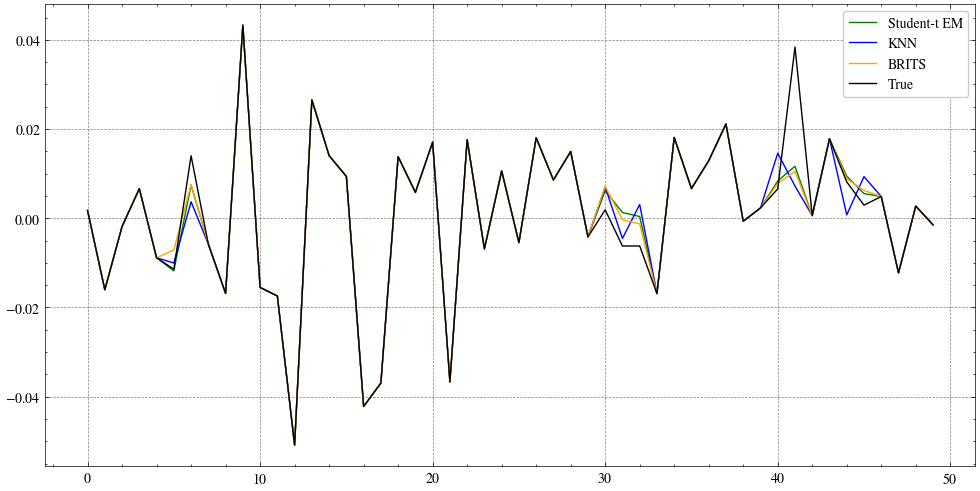

In [88]:
plt.figure(figsize=(12, 6))
plt.plot(imputed["Student-t EM"].to_numpy()[:50, 0], label="Student-t EM", color="green")
plt.plot(imputed["KNN"].to_numpy()[:50, 0], label="KNN", color="blue")
plt.plot(imputed["BRITS"].to_numpy()[:50, 0], label="BRITS", color="orange")
plt.plot(X_true[:50, 0], label="True", color="black")
plt.legend()
#plt.savefig("imputation_comparison.pdf", bbox_inches="tight")
plt.show()
